# 🏠 California House Price Prediction with Neural Networks

This notebook demonstrates how to build a **neural network** to predict house prices using the California Housing dataset.

## What we'll learn:
- **Data loading and preprocessing** with scikit-learn
- **Building a neural network** with PyTorch
- **Training with regularization** (Dropout + L2)
- **Evaluating model performance** on test data
- **Visualizing results** and understanding parameter effects

---

In [20]:
%pip install torch scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# --- Tools we need for our exercise---
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
# Additional imports for visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading & Exploration

The **California Housing dataset** contains information about houses in California districts. Each sample has 8 features describing the district and the median house price.

In [23]:
# 1) LOAD THE DATA
data     = fetch_california_housing()
features = data.data  # 8 input numbers for each house
prices   = data.target.reshape(-1, 1)  # Reshape per lo scaler

print(f"Number of samples: {len(prices)}")
print(f"Number of features: {features.shape[1]}")
print(f"Feature names: {data.feature_names}")

Number of samples: 20640
Number of features: 8
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


C:\Users\demar\AppData\Local\Temp\ipykernel_27144\1969426144.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\demar\AppData\Local\Temp\ipykernel_27144\1969426144.py:34: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\demar\AppData\Local\Temp\ipykernel_27144\1969426144.py:34: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\demar\AppData\Local\Temp\ipykernel_27144\1969426144.py:34: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\demar\AppData\Local\Temp\ipykernel_27144\1969426144.py:34: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
c:\Program Files\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_i

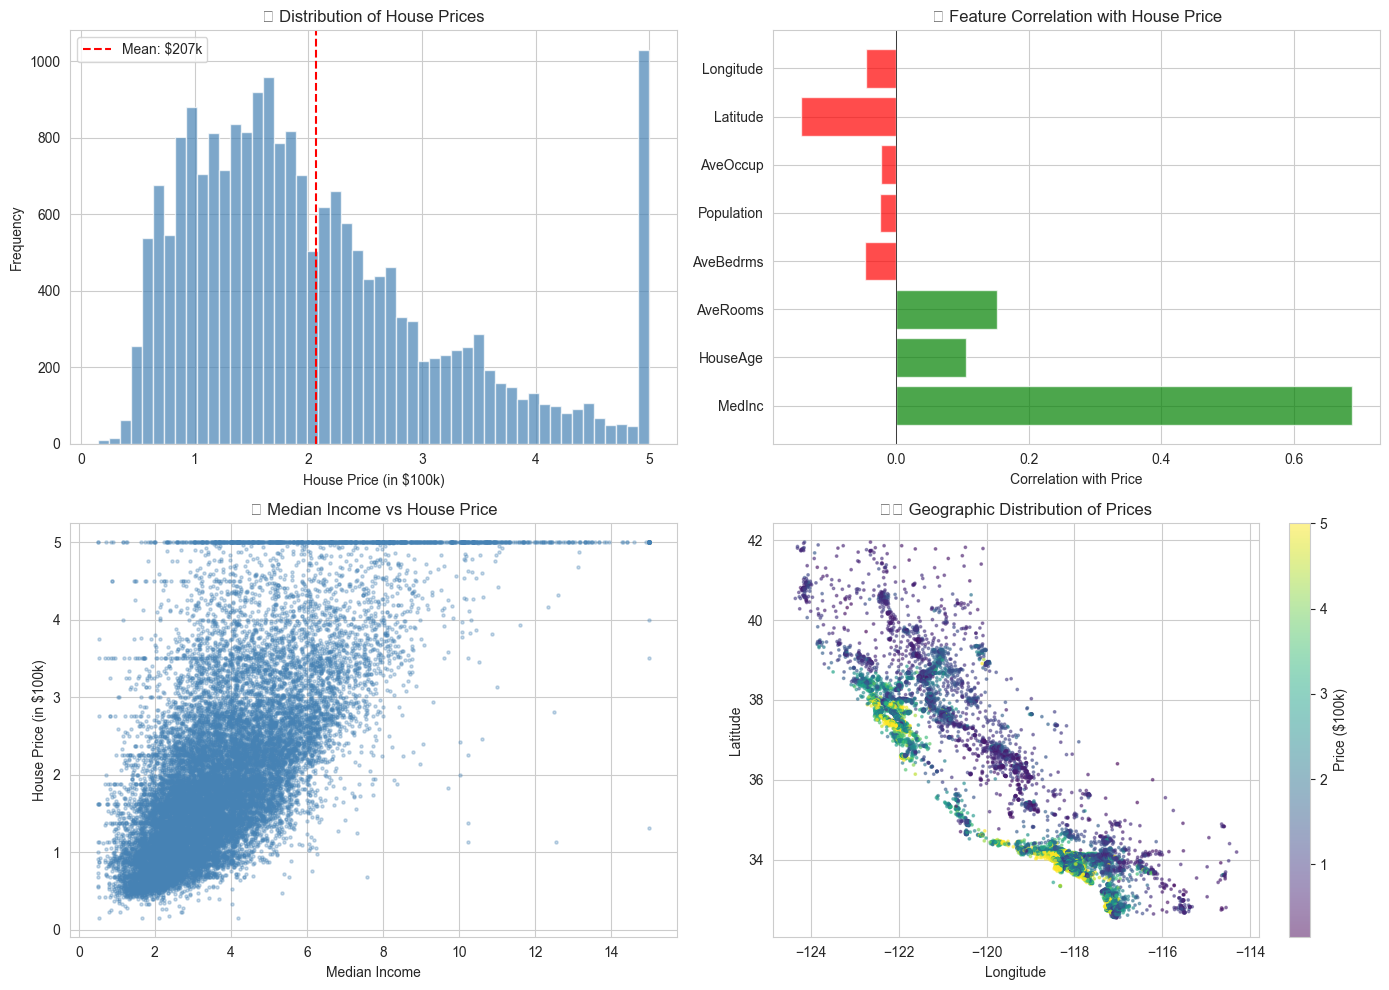

In [24]:
# --- Data Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of house prices
axes[0, 0].hist(prices, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0, 0].set_xlabel('House Price (in $100k)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('📊 Distribution of House Prices')
axes[0, 0].axvline(np.mean(prices), color='red', linestyle='--', label=f'Mean: ${np.mean(prices)*100:.0f}k')
axes[0, 0].legend()

# 2. Feature correlation with price
correlations = [np.corrcoef(features[:, i], prices.flatten())[0, 1] for i in range(features.shape[1])]
colors = ['green' if c > 0 else 'red' for c in correlations]
axes[0, 1].barh(data.feature_names, correlations, color=colors, alpha=0.7)
axes[0, 1].set_xlabel('Correlation with Price')
axes[0, 1].set_title('📈 Feature Correlation with House Price')
axes[0, 1].axvline(0, color='black', linewidth=0.5)

# 3. Median Income vs Price (strongest correlation)
axes[1, 0].scatter(features[:, 0], prices, alpha=0.3, s=5, c='steelblue')
axes[1, 0].set_xlabel('Median Income')
axes[1, 0].set_ylabel('House Price (in $100k)')
axes[1, 0].set_title('💰 Median Income vs House Price')

# 4. Geographic distribution
scatter = axes[1, 1].scatter(features[:, 7], features[:, 6], c=prices.flatten(), 
                              cmap='viridis', alpha=0.5, s=3)
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')
axes[1, 1].set_title('🗺️ Geographic Distribution of Prices')
plt.colorbar(scatter, ax=axes[1, 1], label='Price ($100k)')

plt.tight_layout()
plt.show()

## 2. Data Preparation

We split the data into three sets:
- **Training set (70%)**: The model learns from this data
- **Validation set (15%)**: Used to monitor training and prevent overfitting  
- **Test set (15%)**: Final evaluation on unseen data

In [25]:
# 2) SPLIT THE DATA (aggiungiamo anche validation set)

# We divide the dataset into 3 parts:
# training (learn), validation (check progress), test (final evaluation)

train_features, temp_features, train_prices, temp_prices = train_test_split(
    features, prices, test_size=0.3, random_state=42
)

val_features, test_features, val_prices, test_prices = train_test_split(
    temp_features, temp_prices, test_size=0.5, random_state=42
)

# Show how many samples are in each group
print("Training samples:", len(train_prices))
print("Validation samples:", len(val_prices))
print("Test samples:", len(test_prices))


Training samples: 14448
Validation samples: 3096
Test samples: 3096


In [26]:
# 3) SCALE THE DATA

# We rescale the data so all numbers are comparable
# (mean = 0, standard deviation = 1)

feature_scaler = StandardScaler()
price_scaler = StandardScaler()

# Scale input data (house features)
train_features = feature_scaler.fit_transform(train_features)
val_features   = feature_scaler.transform(val_features)
test_features  = feature_scaler.transform(test_features)

# Scale output data (house prices)
train_prices = price_scaler.fit_transform(train_prices)
val_prices   = price_scaler.transform(val_prices)
test_prices  = price_scaler.transform(test_prices)

print("Data scaled: all values now have similar size")


Data scaled: all values now have similar size


### Why do we scale the data?

**Standardization** (mean=0, std=1) helps neural networks:
- Learn faster (similar scale for all features)
- Avoid numerical instability
- Treat all features equally initially

In [27]:
# 4) CONVERT TO PYTORCH TENSORS
train_features = torch.tensor(train_features, dtype=torch.float32)
train_prices   = torch.tensor(train_prices, dtype=torch.float32)

val_features = torch.tensor(val_features, dtype=torch.float32)
val_prices = torch.tensor(val_prices, dtype=torch.float32)

test_features  = torch.tensor(test_features, dtype=torch.float32)
test_prices = torch.tensor(test_prices, dtype=torch.float32)


## 3. Neural Network Architecture

Our model uses:
- **6 layers** with decreasing neurons (256 → 128 → 64 → 32 → 16 → 1)
- **ReLU activation** for non-linearity
- **Dropout regularization** to prevent overfitting

```
Input (8 features) → 256 → 128 → 64 → 32 → 16 → 1 (price prediction)
```

In [28]:
# 5) MODELLO CON DROPOUT PER REGOLARIZZAZIONE
class HousePriceModel(nn.Module):
    def __init__(self, n_features, dropout_rate=0.1):
        super().__init__()
        
        # Modello con dropout per regolarizzazione
        self.network = nn.Sequential(
            nn.Linear(n_features, 256),    # First layer from input features to 256 neurons
            nn.ReLU(),                     # Non-linear activation
            nn.Dropout(dropout_rate),      # Dropout after first hidden layer

            nn.Linear(256, 128),           # Second  layer
            nn.ReLU(),                     # Non-linear activation
            nn.Dropout(dropout_rate),      # Dropout after second  layer

            nn.Linear(128, 64),            # Third  layer
            nn.ReLU(),
            nn.Dropout(dropout_rate),      # Dropout after third layer

            nn.Linear(64, 32),             # Fourth layer
            nn.ReLU(),                     # Non-linear activation

            nn.Linear(32, 16),             # Fifth layer
            nn.ReLU(),                     # Non-linear activation

            nn.Linear(16, 1)               # Output layer (no dropout here)
        )

    def forward(self, x):
        return self.network(x)


model = HousePriceModel(train_features.shape[1], dropout_rate=0.1)
print(model)


HousePriceModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=16, bias=True)
    (12): ReLU()
    (13): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 4. Training the Model

**Key hyperparameters:**
- `learning_rate`: How big each learning step is
- `weight_decay`: L2 regularization strength
- `dropout_rate`: Fraction of neurons to disable during training
- `epochs`: Number of training iterations

In [29]:
# We measure how wrong the predictions are
loss_function = nn.MSELoss()

# How big each learning step is
learning_rate = 0.005

# Weight decay (L2 regularization) - penalizes large weights
weight_decay = 3e-3

# Tool that updates the model to make predictions better
# Added weight_decay for L2 regularization
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# How many times we repeat the learning process
number_of_epochs = 2000

# Track training history for visualization
train_losses = []
val_losses = []

for epoch in range(number_of_epochs):

    # --- TRAINING ---
    model.train()                         # learning mode (dropout active)
    predicted_prices = model(train_features)
    train_loss = loss_function(predicted_prices, train_prices)

    optimizer.zero_grad()                 # reset old gradients
    train_loss.backward()                 # understand mistakes
    optimizer.step()                      # improve the model

    # --- VALIDATION ---
    model.eval()                          # evaluation mode (dropout disabled)
    with torch.no_grad():
        val_predictions = model(val_features)
        val_loss = loss_function(val_predictions, val_prices)

    # Store losses for plotting
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    # Print progress sometimes
    if epoch % 50 == 0:
        print(
            f"Epoch {epoch} | "
            f"Train error: {train_loss.item():.4f} | "
            f"Validation error: {val_loss.item():.4f}"
        )

Epoch 0 | Train error: 1.0578 | Validation error: 0.9816
Epoch 50 | Train error: 0.3133 | Validation error: 0.3118
Epoch 100 | Train error: 0.2650 | Validation error: 0.2551
Epoch 150 | Train error: 0.2341 | Validation error: 0.2392
Epoch 200 | Train error: 0.2233 | Validation error: 0.2260
Epoch 250 | Train error: 0.2203 | Validation error: 0.2225
Epoch 300 | Train error: 0.2094 | Validation error: 0.2186
Epoch 350 | Train error: 0.2117 | Validation error: 0.2160
Epoch 400 | Train error: 0.2052 | Validation error: 0.2133
Epoch 450 | Train error: 0.1978 | Validation error: 0.2161
Epoch 500 | Train error: 0.2205 | Validation error: 0.2500
Epoch 550 | Train error: 0.1940 | Validation error: 0.2060
Epoch 600 | Train error: 0.1922 | Validation error: 0.2086
Epoch 650 | Train error: 0.1892 | Validation error: 0.2065
Epoch 700 | Train error: 0.1874 | Validation error: 0.2042
Epoch 750 | Train error: 0.2034 | Validation error: 0.2129
Epoch 800 | Train error: 0.2151 | Validation error: 0.2309


C:\Users\demar\AppData\Local\Temp\ipykernel_27144\2174635562.py:21: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\demar\AppData\Local\Temp\ipykernel_27144\2174635562.py:21: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Program Files\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Program Files\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


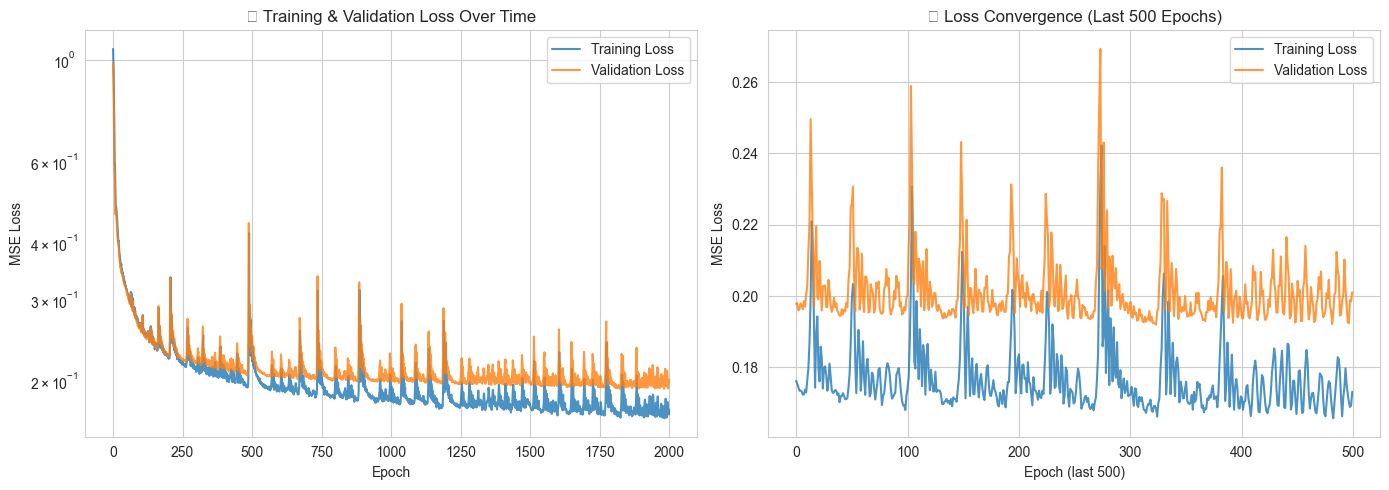


✅ Final Training Loss: 0.1731
✅ Final Validation Loss: 0.2011


In [30]:
# --- Training History Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Training Loss', alpha=0.8)
axes[0].plot(val_losses, label='Validation Loss', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('📉 Training & Validation Loss Over Time')
axes[0].legend()
axes[0].set_yscale('log')

# Zoomed view (last 500 epochs)
axes[1].plot(train_losses[-500:], label='Training Loss', alpha=0.8)
axes[1].plot(val_losses[-500:], label='Validation Loss', alpha=0.8)
axes[1].set_xlabel('Epoch (last 500)')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('🔍 Loss Convergence (Last 500 Epochs)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n✅ Final Training Loss: {train_losses[-1]:.4f}")
print(f"✅ Final Validation Loss: {val_losses[-1]:.4f}")

## 5. Model Evaluation

Let's evaluate our model on the **test set** (data it has never seen during training).

In [31]:
# 7) EVALUATE ON TEST SET

# Switch the model to evaluation mode
model.eval()
with torch.no_grad():
    test_predictions_scaled = model(test_features).cpu().numpy()

# De-scale predictions and targets to original units (prices in $100k)
test_predictions = price_scaler.inverse_transform(test_predictions_scaled)
test_prices_original = price_scaler.inverse_transform(test_prices.cpu().numpy())

# Calculate metrics on original values
mae = np.mean(np.abs(test_predictions - test_prices_original))
rmse = np.sqrt(np.mean((test_predictions - test_prices_original) ** 2))
mape = np.mean(np.abs((test_predictions - test_prices_original) / test_prices_original)) * 100

# Calculate R² score
ss_res = np.sum((test_prices_original - test_predictions) ** 2)
ss_tot = np.sum((test_prices_original - np.mean(test_prices_original)) ** 2)
r2_score = 1 - (ss_res / ss_tot)

# Display results in a clear format
print("=" * 60)
print("                    FINAL RESULTS")
print("=" * 60)
print()
print("Model Performance Metrics:")
print("-" * 40)
print(f"   Mean Absolute Error:     ${mae * 100000:>12,.0f}")
print(f"   Mean Absolute % Error:        {mape:>12.2f}%")

                    FINAL RESULTS

Model Performance Metrics:
----------------------------------------
   Mean Absolute Error:     $      31,648
   Mean Absolute % Error:               17.09%


C:\Users\demar\AppData\Local\Temp\ipykernel_27144\2515597434.py:34: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\demar\AppData\Local\Temp\ipykernel_27144\2515597434.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\demar\AppData\Local\Temp\ipykernel_27144\2515597434.py:34: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  plt.tight_layout()
c:\Program Files\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Program Files\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Program Files\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font

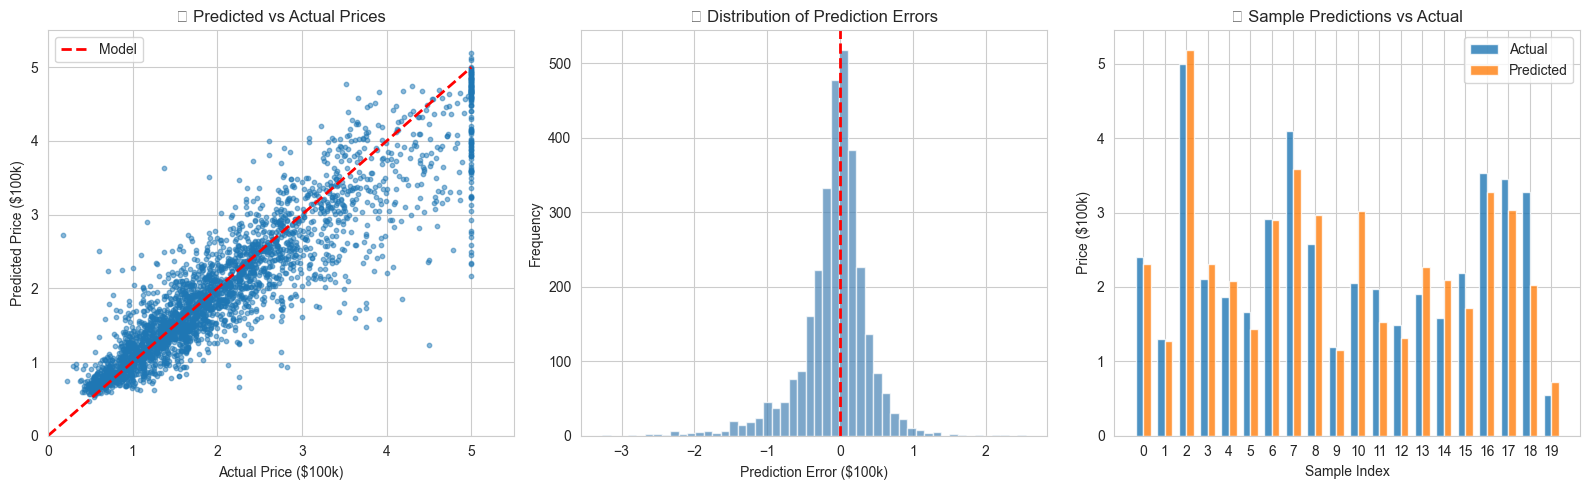

In [32]:
# --- Prediction Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Predicted vs Actual scatter plot
axes[0].scatter(test_prices_original, test_predictions, alpha=0.5, s=10)
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Model')
axes[0].set_xlabel('Actual Price ($100k)')
axes[0].set_ylabel('Predicted Price ($100k)')
axes[0].set_title('🎯 Predicted vs Actual Prices')
axes[0].legend()
axes[0].set_xlim(0, 5.5)
axes[0].set_ylim(0, 5.5)

# 2. Residuals distribution
residuals = test_predictions.flatten() - test_prices_original.flatten()
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error ($100k)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('📊 Distribution of Prediction Errors')

# 3. Sample predictions comparison
sample_idx = np.random.choice(len(test_prices_original), 20, replace=False)
x_pos = np.arange(20)
width = 0.35
axes[2].bar(x_pos - width/2, test_prices_original[sample_idx].flatten(), width, label='Actual', alpha=0.8)
axes[2].bar(x_pos + width/2, test_predictions[sample_idx].flatten(), width, label='Predicted', alpha=0.8)
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Price ($100k)')
axes[2].set_title('🏠 Sample Predictions vs Actual')
axes[2].legend()
axes[2].set_xticks(x_pos)

plt.tight_layout()
plt.show()